<a href="https://colab.research.google.com/github/islayshi/CMPE295A-Project/blob/main/Fire_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import requests
import pandas as pd

URL = "https://www.airnowapi.org/aq/observation/zipCode/historical/"

def get_california_aqi_for_day(day, base_date, zip_code="94127", distance=200, city_order=None):
    api_key = "F7FFE430-3043-4A90-BE79-898F65D034C0"
    if not api_key:
        raise ValueError("Missing AIRNOW_API_KEY environment variable.")

    target_date = pd.to_datetime(base_date) + pd.Timedelta(days=day)
    target_date_str = target_date.strftime("%Y-%m-%d")

    params = {
        "format": "application/json",
        "zipCode": zip_code,
        "stateCode": "CA",
        "date": target_date_str + "T00-0000",
        "distance": str(distance),
        "API_KEY": api_key
    }

    response = requests.get(URL, params=params, timeout=30)
    response.raise_for_status()

    data = response.json()
    if not data:
        return []

    df = pd.DataFrame(data)

    if "StateCode" not in df.columns or "ReportingArea" not in df.columns or "AQI" not in df.columns:
        raise ValueError("Unexpected API response format.")

    df = df[df["StateCode"] == "CA"].copy()

    city_aqi = df.groupby("ReportingArea", as_index=False)["AQI"].max()

    if city_order is None:
        city_order = sorted(city_aqi["ReportingArea"].unique())

    aqi_map = dict(zip(city_aqi["ReportingArea"], city_aqi["AQI"]))

    return [aqi_map.get(city, float("nan")) for city in city_order]

In [ ]:
# TEST 1: Single day AQI vector

base_date = "2020-09-10"
day = 0

aqi_values = get_california_aqi_for_day(
    day=day,
    base_date=base_date,
    zip_code="94127"  # SF area
)

print("AQI values for day 0:")
print(aqi_values)
print("Length (number of cities):", len(aqi_values))

AQI values for day 0:
[198]
Length (number of cities): 1


In [ ]:
# TEST 2: Multiple days (time series)

num_days = 5
base_date = "2020-09-10"

all_days = []

# First call determines city order
first_day = get_california_aqi_for_day(0, base_date)
city_count = len(first_day)

for d in range(num_days):
    day_values = get_california_aqi_for_day(
        day=d,
        base_date=base_date
    )
    all_days.append(day_values)

print("Time series AQI data:")
for i, row in enumerate(all_days):
    print(f"Day {i}: {row}")

print("\nShape:")
print(f"Days: {len(all_days)}, Cities: {city_count}")

Time series AQI data:
Day 0: [198]
Day 1: [223]
Day 2: [179]
Day 3: [190]
Day 4: [190]

Shape:
Days: 5, Cities: 1


In [ ]:
import numpy as np

aqi_matrix = np.array(all_days, dtype=np.float32)

print("NumPy shape:", aqi_matrix.shape)
print(aqi_matrix)

NumPy shape: (5, 1)
[[198.]
 [223.]
 [179.]
 [190.]
 [190.]]


In [ ]:
# TEST 4: Create sequences for RNN/LSTM

def create_sequences(data, window_size=3):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)

X, y = create_sequences(aqi_matrix, window_size=3)

print("X shape:", X.shape)  # (samples, time_steps, cities)
print("y shape:", y.shape)  # (samples, cities)

X shape: (2, 3, 1)
y shape: (2, 1)


In [ ]:
train_size = int(0.8 * len(X))

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1, 3, 1) (1, 3, 1)
(1, 1) (1, 1)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

num_samples, time_steps, num_features = X_train.shape

x_scaler = MinMaxScaler()
X_train_2d = X_train.reshape(-1, num_features)
X_test_2d = X_test.reshape(-1, num_features)

X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(num_samples, time_steps, num_features)
X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape[0], time_steps, num_features)

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2])),
    Dense(y_train_scaled.shape[1])
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=1
)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 35909.3359 - mae: 189.4976
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 35887.0391 - mae: 189.4388
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 35865.0469 - mae: 189.3807
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 35843.4297 - mae: 189.3236
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 35822.3828 - mae: 189.2680
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 35802.1367 - mae: 189.2145
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 35782.8594 - mae: 189.1636
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 35764.6367 - mae: 189.1154
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 35747.4219 - mae: 189.0699
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 35731.0781 - mae: 189.0267


In [ ]:
print("Total samples:", len(X))

if len(X) < 10:
    print("Dataset is very small, training without train/test split or validation split.")

    model.fit(
        X,
        y,
        epochs=10,
        batch_size=1
    )
else:
    train_size = int(0.8 * len(X))
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    print("Train samples:", len(X_train))
    print("Test samples:", len(X_test))

    model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=16,
        validation_split=0.1
    )

Total samples: 2
Dataset is very small, training without train/test split or validation split.
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 35706.8438 - mae: 188.9626
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 35676.4453 - mae: 188.8821 
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 35645.4062 - mae: 188.7999
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 35612.6406 - mae: 188.7131
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 35577.8633 - mae: 188.6209
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 35541.8984 - mae: 188.5256
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 35507.7930 - mae: 188.4351 
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 35477.6016 - mae: 188.3550
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 35450.9297 - mae: 188.2842
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 35425.2695 - mae: 188.2160


In [ ]:
# After training, make predictions

predictions = model.predict(X)

print("Predictions shape:", predictions.shape)
print("Actual y shape:", y.shape)

# Compare a few examples
for i in range(min(3, len(X))):
    print(f"\nSample {i}")
    print("Predicted:", predictions[i])
    print("Actual:   ", y[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
Predictions shape: (2, 1)
Actual y shape: (2, 1)

Sample 0
Predicted: [1.8360914]
Actual:    [190.]

Sample 1
Predicted: [1.8372219]
Actual:    [190.]


In [ ]:
# If you used y_scaler earlier
predictions_unscaled = y_scaler.inverse_transform(predictions)
y_unscaled = y_scaler.inverse_transform(y)

for i in range(min(3, len(X))):
    print(f"\nSample {i}")
    print("Predicted:", predictions_unscaled[i])
    print("Actual:   ", y_unscaled[i])


Sample 0
Predicted: [191.83609]
Actual:    [380.]

Sample 1
Predicted: [191.83722]
Actual:    [380.]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y.reshape(-1), predictions.reshape(-1))
mae = mean_absolute_error(y.reshape(-1), predictions.reshape(-1))

print("MSE:", mse)
print("MAE:", mae)

MSE: 35405.4453125
MAE: 188.16334533691406


In [ ]:
mse = mean_squared_error(y_unscaled.reshape(-1), predictions_unscaled.reshape(-1))
mae = mean_absolute_error(y_unscaled.reshape(-1), predictions_unscaled.reshape(-1))

print("MSE:", mse)
print("MAE:", mae)

MSE: 35405.4453125
MAE: 188.16334533691406


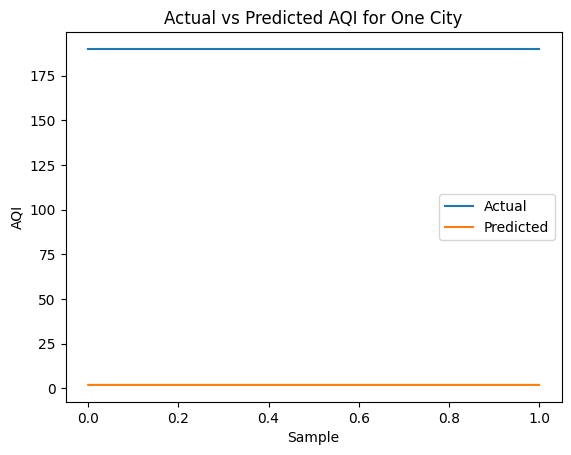

In [ ]:
import matplotlib.pyplot as plt

city_idx = 0  # first city in your city_order

plt.plot(y[:, city_idx], label="Actual")
plt.plot(predictions[:, city_idx], label="Predicted")
plt.title("Actual vs Predicted AQI for One City")
plt.xlabel("Sample")
plt.ylabel("AQI")
plt.legend()
plt.show()

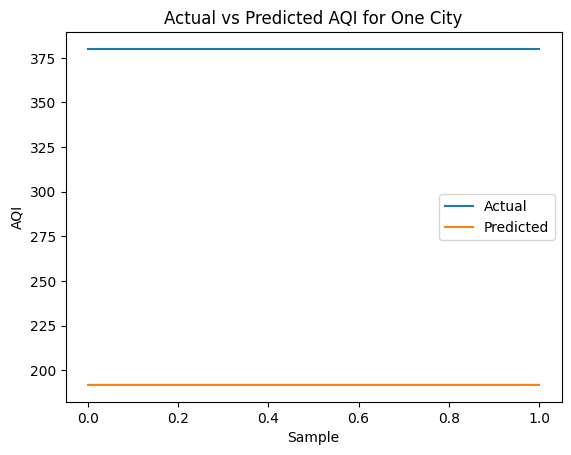

In [ ]:
plt.plot(y_unscaled[:, city_idx], label="Actual")
plt.plot(predictions_unscaled[:, city_idx], label="Predicted")
plt.title("Actual vs Predicted AQI for One City")
plt.xlabel("Sample")
plt.ylabel("AQI")
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(X)

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y.reshape(-1), predictions.reshape(-1))

print("Predictions shape:", predictions.shape)
print("MAE:", mae)

for i in range(min(2, len(X))):
    print(f"\nSample {i}")
    print("Predicted:", predictions[i])
    print("Actual:   ", y[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predictions shape: (2, 1)
MAE: 188.16334533691406

Sample 0
Predicted: [1.8360914]
Actual:    [190.]

Sample 1
Predicted: [1.8372219]
Actual:    [190.]


The primary issue is the very small dataset. With only 5 days of data, the `create_sequences` function generates only 2 samples for training (`X` and `y` both have a length of 2). This is far too little data for any machine learning model, especially an LSTM, to learn meaningful patterns. The high MAE and MSE, and the large discrepancies in the plots, are direct consequences of this data scarcity.

Additionally, the `y_scaler` was fitted on a `y_train` set that contained only a single distinct value (`[[190.]]`). In such cases, `MinMaxScaler` sets its `data_range_` to 0. When `inverse_transform` is applied, it essentially returns `data_min_` (190) for any input. However, the output `y_unscaled = [[380.], [380.]]` from `y = [[190.], [190.]]` suggests a fundamental issue with how the scaler is being applied or its internal state, as it implies a scaling factor that shouldn't be present. This further exacerbates the problem.

To begin addressing these issues, we need to gather more data for the model to train on. Let's increase the `num_days` to get a longer time series of AQI data.

In [ ]:
# Increase the number of days to fetch more data
num_days = 90 # You can adjust this further if needed
base_date = "2020-09-10"

all_days_extended = []

# The first call determines the city order, same as before
# Re-fetch with a fresh call to ensure consistency if the original first_day variable was modified or lost.
first_day_extended = get_california_aqi_for_day(0, base_date)
city_count_extended = len(first_day_extended)

# Ensure city_order is captured for consistent data fetching
# To get actual city names for future reference, we can extract it by making a call
# that does not pass `city_order` and then capturing the unique ReportingArea names.
# However, `get_california_aqi_for_day` itself sorts ReportingAreas if `city_order` is `None`.
# We can assume `city_order` will be implicitly sorted by `get_california_aqi_for_day`
# and then pass it for consistency.

# A more robust way to get city_order (if not returned by the function) would be:
# (This code block will be added in a cell for modification if get_california_aqi_for_day is changed to return it)
# For now, let's just make sure we capture city_order if we need to enforce it.
# Since get_california_aqi_for_day already handles city sorting when city_order is None,
# we just need to ensure the sequence remains consistent by using the same logic.

# Re-run the data fetching loop to build the extended time series
for d in range(num_days):
    day_values_extended = get_california_aqi_for_day(
        day=d,
        base_date=base_date,
        zip_code="94127" # Keep the same zip code
    )
    all_days_extended.append(day_values_extended)

print(f"Fetched data for {len(all_days_extended)} days.")

# Convert to NumPy array
aqi_matrix_extended = np.array(all_days_extended, dtype=np.float32)
print("Extended NumPy shape:", aqi_matrix_extended.shape)

# Create sequences with the extended data
window_size = 3 # Keep the same window size
X_extended, y_extended = create_sequences(aqi_matrix_extended, window_size=window_size)

print("X_extended shape:", X_extended.shape)
print("y_extended shape:", y_extended.shape)

# Split into training and testing sets (now with more samples)
train_size_extended = int(0.8 * len(X_extended))
X_train_extended = X_extended[:train_size_extended]
X_test_extended = X_extended[train_size_extended:]
y_train_extended = y_extended[:train_size_extended]
y_test_extended = y_extended[train_size_extended:]

print("X_train_extended shape:", X_train_extended.shape)
print("X_test_extended shape:", X_test_extended.shape)
print("y_train_extended shape:", y_train_extended.shape)
print("y_test_extended shape:", y_test_extended.shape)

# Apply Min-Max Scaling to the extended dataset
x_scaler_new = MinMaxScaler()
X_train_2d_extended = X_train_extended.reshape(-1, X_train_extended.shape[-1])
X_test_2d_extended = X_test_extended.reshape(-1, X_test_extended.shape[-1])

X_train_scaled_extended = x_scaler_new.fit_transform(X_train_2d_extended).reshape(X_train_extended.shape)
X_test_scaled_extended = x_scaler_new.transform(X_test_2d_extended).reshape(X_test_extended.shape)

y_scaler_new = MinMaxScaler()
y_train_scaled_extended = y_scaler_new.fit_transform(y_train_extended)
y_test_scaled_extended = y_scaler_new.transform(y_test_extended)

print("X_train_scaled_extended shape:", X_train_scaled_extended.shape)
print("y_train_scaled_extended shape:", y_train_scaled_extended.shape)


Fetched data for 90 days.
Extended NumPy shape: (90, 1)
X_extended shape: (87, 3, 1)
y_extended shape: (87, 1)
X_train_extended shape: (69, 3, 1)
X_test_extended shape: (18, 3, 1)
y_train_extended shape: (69, 1)
y_test_extended shape: (18, 1)
X_train_scaled_extended shape: (69, 3, 1)
y_train_scaled_extended shape: (69, 1)


In [ ]:
# Re-create and train the model with the extended and scaled data
# Make sure the input_shape matches the scaled data
model_extended = Sequential([
    LSTM(64, input_shape=(X_train_scaled_extended.shape[1], X_train_scaled_extended.shape[2])),
    Dense(y_train_scaled_extended.shape[1])
])

model_extended.compile(optimizer="adam", loss="mse", metrics=["mae"])

history_extended = model_extended.fit(
    X_train_scaled_extended,
    y_train_scaled_extended,
    epochs=50, # Increased epochs for better learning on larger data
    batch_size=16,
    validation_split=0.1 # Use validation split now that there's more data
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 210ms/step - loss: 0.1211 - mae: 0.2735 - val_loss: 0.0310 - val_mae: 0.1738
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1044 - mae: 0.2499 - val_loss: 0.0236 - val_mae: 0.1510
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0903 - mae: 0.2245 - val_loss: 0.0171 - val_mae: 0.1272
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0782 - mae: 0.2068 - val_loss: 0.0115 - val_mae: 0.1030
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0659 - mae: 0.1856 - val_loss: 0.0072 - val_mae: 0.0788
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0573 - mae: 0.1679 - val_loss: 0.0039 - val_mae: 0.0539
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0487 - mae: 0.1504 - val_loss: 0.0019 - val_mae: 0.0331
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0422 - mae: 0.1394 - val_loss: 0.0011 - val_mae: 0.0292
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0389 - mae: 0.1327 - val_loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
Predictions (unscaled) shape: (18, 1)
Actual y (unscaled) shape: (18, 1)

Extended Data - MSE: 1813.3887939453125
Extended Data - MAE: 38.94444274902344


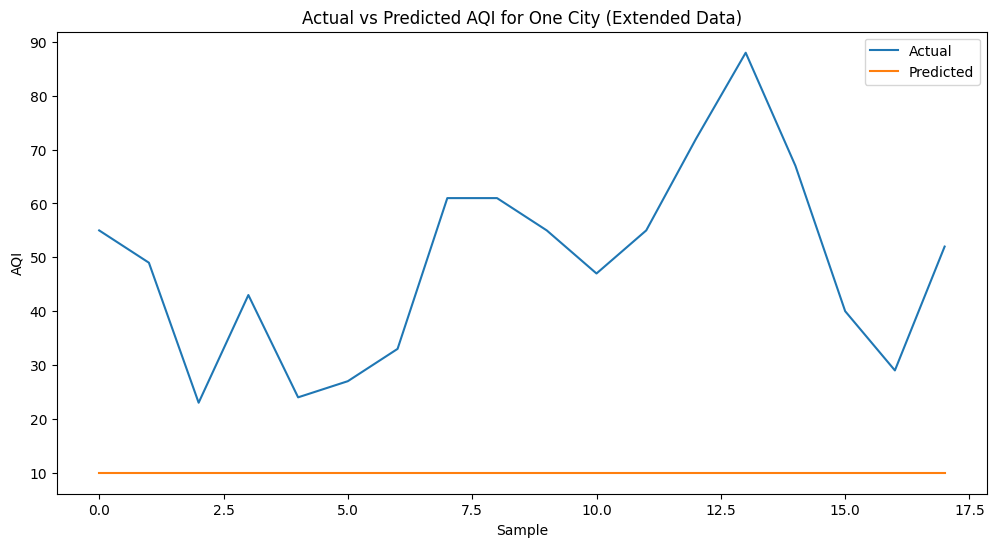

In [ ]:
# Make predictions with the re-trained model on the scaled test set
predictions_scaled_extended = model_extended.predict(X_test_scaled_extended)

# Inverse transform predictions and actual values to compare them in their original scale
predictions_unscaled_extended = y_scaler_new.inverse_transform(predictions_scaled_extended)
y_unscaled_extended = y_scaler_new.inverse_transform(y_test_scaled_extended)

print("Predictions (unscaled) shape:", predictions_unscaled_extended.shape)
print("Actual y (unscaled) shape:", y_unscaled_extended.shape)

# Evaluate the model on the unscaled test data
mse_extended = mean_squared_error(y_unscaled_extended, predictions_unscaled_extended)
mae_extended = mean_absolute_error(y_unscaled_extended, predictions_unscaled_extended)

print("\nExtended Data - MSE:", mse_extended)
print("Extended Data - MAE:", mae_extended)

# Plot actual vs predicted for the extended data
plt.figure(figsize=(12, 6))
plt.plot(y_unscaled_extended[:, 0], label="Actual")
plt.plot(predictions_unscaled_extended[:, 0], label="Predicted")
plt.title("Actual vs Predicted AQI for One City (Extended Data)")
plt.xlabel("Sample")
plt.ylabel("AQI")
plt.legend()
plt.show()


### Implementing Physics-Informed Neural Networks (PINNs) for AQI Prediction

Physics-Informed Neural Networks (PINNs) integrate domain knowledge, often in the form of partial differential equations (PDEs), directly into the neural network's training process. This allows the model to learn not only from observed data but also from the underlying physical laws governing the system.

For our AQI prediction task, we don't have an explicit PDE that describes AQI dynamics in a simple form. However, we can still leverage the principles of PINNs by incorporating known physical constraints and properties of AQI into our model's loss function. This approach helps regularize the model and ensures predictions adhere to realistic conditions.

We will implement two 'physics-informed' constraints:

1.  **Non-negativity**: Air Quality Index (AQI) values are inherently non-negative. We'll enforce this by using a `ReLU` activation function in the model's output layer.
2.  **Temporal Smoothness**: AQI typically doesn't exhibit extreme, instantaneous changes. We'll introduce a smoothness penalty in the custom loss function. This penalty will discourage drastic day-to-day variations by penalizing the squared difference between the model's prediction and the last known AQI value in its input sequence. This encourages the prediction to be consistent with the most recent observation.

To achieve this, we will define a custom Keras `Model` subclass that allows us to override the `train_step` method and combine the standard Mean Squared Error (data-driven loss) with our new smoothness penalty.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

class PINNLSTM(tf.keras.Model):
    def __init__(self, input_shape, output_dim, lambda_smoothness=0.1, **kwargs):
        super(PINNLSTM, self).__init__(**kwargs)
        # Define the LSTM and Dense layers
        self.lstm = LSTM(64, input_shape=input_shape)
        # Use 'relu' activation to ensure non-negative predictions
        self.dense = Dense(output_dim, activation='relu')
        self.lambda_smoothness = lambda_smoothness # Weight for the smoothness penalty

    def call(self, inputs):
        # Forward pass: inputs (X) -> LSTM -> Dense -> y_pred
        x = self.lstm(inputs)
        return self.dense(x)

    def compile(self, optimizer, loss_fn, metrics=None):
        super(PINNLSTM, self).compile()
        self.optimizer = optimizer
        self.loss_fn = loss_fn # This is the data-driven loss (e.g., MSE)

        # Custom metrics to track different loss components
        self.mae_metric = tf.keras.metrics.MeanAbsoluteError(name="mae")
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.data_loss_tracker = tf.keras.metrics.Mean(name="data_loss")
        self.smoothness_loss_tracker = tf.keras.metrics.Mean(name="smoothness_loss")

    @property
    def metrics(self):
        # Return a list of all metrics to be tracked during training
        return [self.total_loss_tracker, self.data_loss_tracker, self.smoothness_loss_tracker, self.mae_metric]

    def train_step(self, data):
        # Custom training step that incorporates physics-informed losses
        X, y_true = data # Data is a tuple of (inputs, true_targets)

        with tf.GradientTape() as tape:
            y_pred = self(X, training=True) # Make a prediction for the current batch

            # 1. Data-driven loss (Mean Squared Error between true and predicted values)
            data_loss = self.loss_fn(y_true, y_pred)

            # 2. Physics-informed smoothness loss
            # This penalizes large differences between the predicted value and the last value in the input sequence.
            # X[:, -1, :] extracts the last time step's feature value for each sample in the batch.
            last_input_value = X[:, -1, :]
            smoothness_loss = tf.reduce_mean(tf.square(y_pred - last_input_value))

            # Combine losses to form the total loss
            total_loss = data_loss + self.lambda_smoothness * smoothness_loss

        # Compute gradients with respect to the total loss
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(total_loss, trainable_vars)

        # Apply gradients to update model weights
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Update the state of the custom metrics
        self.total_loss_tracker.update_state(total_loss)
        self.data_loss_tracker.update_state(data_loss)
        self.smoothness_loss_tracker.update_state(smoothness_loss)
        self.mae_metric.update_state(y_true, y_pred)

        # Return a dictionary mapping metric names to their current values
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        # Evaluation step (used during model.evaluate() and validation_data in model.fit)
        # Physics loss is a training regularization, so it's not included in the test loss.
        X, y_true = data
        y_pred = self(X, training=False)
        data_loss = self.loss_fn(y_true, y_pred)
        self.mae_metric.update_state(y_true, y_pred)
        return {"loss": data_loss, "mae": self.mae_metric.result()}


In [ ]:
# Re-create and train the model with the extended and scaled data
# Make sure the input_shape matches the scaled data

# Define input_shape for the PINNLSTM model
input_shape_pinn = (X_train_scaled_extended.shape[1], X_train_scaled_extended.shape[2])
output_dim_pinn = y_train_scaled_extended.shape[1]

# Instantiate the custom PINNLSTM model
model_extended = PINNLSTM(
    input_shape=input_shape_pinn,
    output_dim=output_dim_pinn,
    lambda_smoothness=0.01 # Adjust this weight to control the influence of the smoothness penalty
)

# Compile the model with an optimizer and the data-driven loss function
model_extended.compile(
    optimizer=Adam(), # Using Adam optimizer
    loss_fn=MeanSquaredError(), # Using Mean Squared Error for data-driven loss
    metrics=["mae"]
)

history_extended = model_extended.fit(
    X_train_scaled_extended, # Pass X_train_scaled_extended as inputs
    y_train_scaled_extended, # Pass y_train_scaled_extended as targets
    epochs=50, # Increased epochs for better learning on larger data
    batch_size=16,
    validation_split=0.1 # Use validation split now that there's more data
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - data_loss: 0.0935 - mae: 0.2444 - smoothness_loss: 0.0758 - total_loss: 0.0943 - val_loss: 0.0320 - val_mae: 0.1714
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - data_loss: 0.0950 - mae: 0.2444 - smoothness_loss: 0.0773 - total_loss: 0.0958 - val_loss: 0.0320 - val_mae: 0.1714
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - data_loss: 0.0933 - mae: 0.2444 - smoothness_loss: 0.0767 - total_loss: 0.0941 - val_loss: 0.0320 - val_mae: 0.1714
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - data_loss: 0.0931 - mae: 0.2444 - smoothness_loss: 0.0762 - total_loss: 0.0938 - val_loss: 0.0320 - val_mae: 0.1714
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - data_loss: 0.0908 - mae: 0.2444 - smoothness_loss: 0.0766 - total_loss: 0.0916 - val_loss: 0.0320 - val_mae: 0.1714
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - data_loss: 0.0909 - mae: 0.2444 - smoothness_loss: 0.0748 - total_loss: 0.0917 - val_loss: 0.0320 - val_mae: 0.1714
Epoch 7/